In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

# Loading all datasets
train = pd.read_csv('../data/train.csv', parse_dates=['date'])
stores = pd.read_csv('../data/stores.csv')
oil = pd.read_csv('../data/oil.csv', parse_dates=['date'])
holidays = pd.read_csv('../data/holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv('../data/transactions.csv', parse_dates=['date'])

print("Datasets loaded successfully!\n")
print(f"Train:        {train.shape[0]:>12,} rows  |  {train.shape[1]} columns")
print(f"Stores:       {stores.shape[0]:>12,} rows  |  {stores.shape[1]} columns")
print(f"Oil:          {oil.shape[0]:>12,} rows  |  {oil.shape[1]} columns")
print(f"Holidays:     {holidays.shape[0]:>12,} rows  |  {holidays.shape[1]} columns")
print(f"Transactions: {transactions.shape[0]:>12,} rows  |  {transactions.shape[1]} columns")

Datasets loaded successfully!

Train:           3,000,888 rows  |  6 columns
Stores:                 54 rows  |  5 columns
Oil:                 1,218 rows  |  2 columns
Holidays:              350 rows  |  6 columns
Transactions:       83,488 rows  |  3 columns


So what we can see is there  3000888 sells across 54 stores


In [15]:
# Let's see what each dataset looks like
print("=" * 60)
print("TRAIN (main sales data)")
print("=" * 60)
print(train.head(10))
print(f"\nDate range: {train['date'].min()} to {train['date'].max()}")
print(f"\nColumn types:\n{train.dtypes}")
print(f"\nUnique stores: {train['store_nbr'].nunique()}")
print(f"Unique product families: {train['family'].nunique()}")
print(f"\nProduct families:\n{train['family'].unique()}")

TRAIN (main sales data)
   id       date  store_nbr        family  sales  onpromotion
0   0 2013-01-01          1    AUTOMOTIVE    0.0            0
1   1 2013-01-01          1     BABY CARE    0.0            0
2   2 2013-01-01          1        BEAUTY    0.0            0
3   3 2013-01-01          1     BEVERAGES    0.0            0
4   4 2013-01-01          1         BOOKS    0.0            0
5   5 2013-01-01          1  BREAD/BAKERY    0.0            0
6   6 2013-01-01          1   CELEBRATION    0.0            0
7   7 2013-01-01          1      CLEANING    0.0            0
8   8 2013-01-01          1         DAIRY    0.0            0
9   9 2013-01-01          1          DELI    0.0            0

Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00

Column types:
id                      int64
date           datetime64[us]
store_nbr               int64
family                    str
sales                 float64
onpromotion             int64
dtype: object

Unique stores: 54
Unique pro

Now we can see the structure clearly. Each row represents one product family at one store on one date. So for any given day, there are 54 stores × 33 product families = 1,782 rows. Over about 4.5 years of data, that gives us the 3 million rows.

In [16]:
print("=" * 60)
print("STORES")
print("=" * 60)
print(stores.head(10))
print(f"\nMissing values: {stores['store_nbr'].isna().sum()} out of {len(stores)}")

print("\n" + "=" * 60)
print("OIL PRICES")
print("=" * 60)
print(oil.head())
print(f"\nMissing values: {oil['dcoilwtico'].isna().sum()} out of {len(oil)}")

print("\n" + "=" * 60)
print("HOLIDAYS")
print("=" * 60)
print(holidays.head(10))
print(f"\nMissing values: {holidays['type'].isna().sum()} out of {len(holidays)}")
print(f"\nHoliday types: {holidays['type'].unique()}")
print(f"Locale types:  {holidays['locale'].unique()}")

print("\n" + "=" * 60)
print("TRANSACTIONS")
print("=" * 60)
print(transactions.head())
print(f"\nMissing values: {transactions['transactions'].isna().sum()} out of {len(transactions)}")

STORES
   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4
5          6          Quito                       Pichincha    D       13
6          7          Quito                       Pichincha    D        8
7          8          Quito                       Pichincha    D        8
8          9          Quito                       Pichincha    B        6
9         10          Quito                       Pichincha    C       15

Missing values: 0 out of 54

OIL PRICES
        date  dcoilwtico
0 2013-01-01         NaN
1 2013-01-02       93.14
2 2013-01-03       92.97
3 2013-01-04       93.12
4 2013-01-07 

Train data is clean  no missing values, 4.5 years of daily sales across 54 stores and 33 product families.
Stores has useful metadata  city, state, store type (A through E), and cluster groupings. This will help us understand if certain store types sell differently.
Oil prices has 43 missing values out of 1,218 rows  these are likely weekends/holidays when markets were closed. We'll need to fill those gaps (forward fill makes sense since oil prices don't jump overnight).
Holidays is the most interesting one. Notice the complexity: holidays can be Local (only affects one city), Regional (affects a state), or National (affects everyone). And there's a transferred column — some holidays get moved to different days by the government. This is real-world messiness that we need to handle carefully.
Transactions is clean and will be a powerful featureit tells us how busy each store was on each day.


Now we will look exactly how does the data behaves:


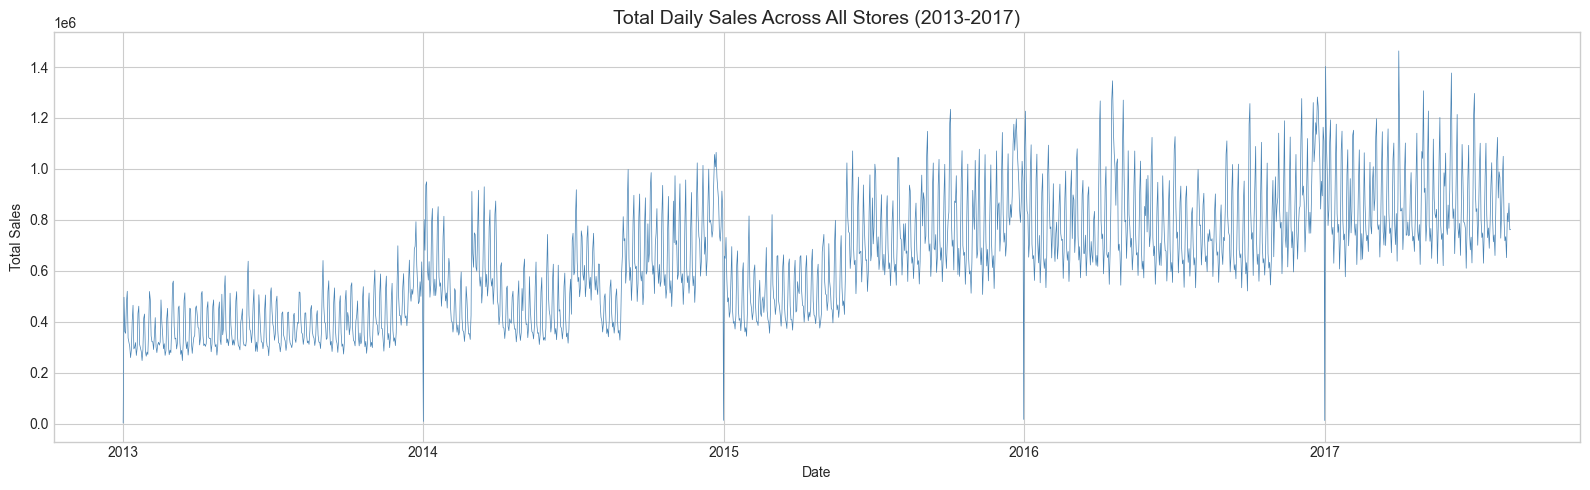

In [17]:
# Aggregating total daily sales across all stores and families
daily_sales = train.groupby('date')['sales'].sum()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_sales.index, daily_sales.values, linewidth=0.5, color='steelblue')
ax.set_title('Total Daily Sales Across All Stores (2013-2017)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
plt.tight_layout()
plt.show()

Upward trend. Sales clearly grow year over year — starting around 400K daily in 2013 and reaching 800K+ by 2017. This means our model needs to capture trend, not just seasonality.
Strong weekly seasonality. Those tight zigzag patterns are weekly cycles — certain days of the week consistently sell more (likely weekends).
Annual spikes. See those sharp peaks around December/January each year?
Sudden drops to near zero. Notice those vertical drops that hit almost zero, happening around January 1st each year. Those are likely store closures on major holidays. This is critical — our model needs to know that a day with zero sales isn't "low demand," it's "the store was closed."

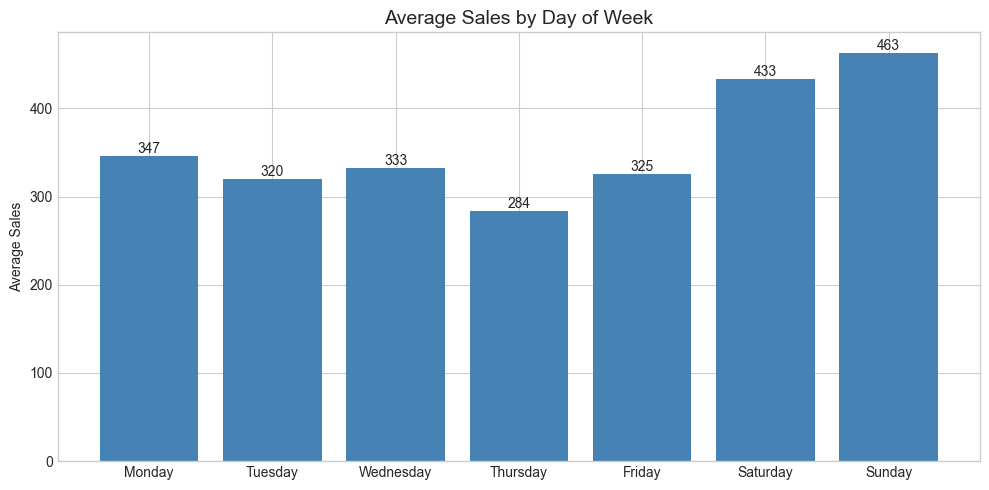

In [18]:
# Sales by day of week
train['day_of_week'] = train['date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily_avg = train.groupby('day_of_week')['sales'].mean().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(daily_avg.index, daily_avg.values, color='steelblue')
ax.set_title('Average Sales by Day of Week', fontsize=14)
ax.set_ylabel('Average Sales')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Now we will look at the monthly sales :

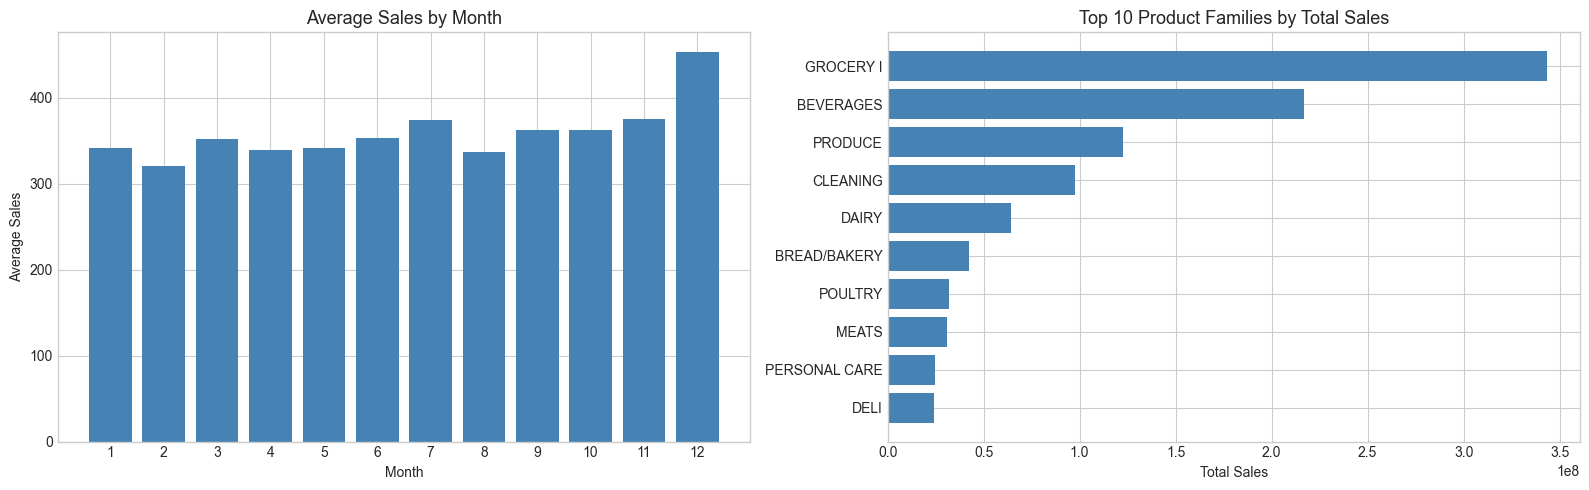

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly average sales
train['month'] = train['date'].dt.month
monthly_avg = train.groupby('month')['sales'].mean()
axes[0].bar(monthly_avg.index, monthly_avg.values, color='steelblue')
axes[0].set_title('Average Sales by Month', fontsize=13)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Sales')
axes[0].set_xticks(range(1, 13))

# Top 10 product families by total sales
family_sales = train.groupby('family')['sales'].sum().sort_values(ascending=True).tail(10)
axes[1].barh(family_sales.index, family_sales.values, color='steelblue')
axes[1].set_title('Top 10 Product Families by Total Sales', fontsize=13)
axes[1].set_xlabel('Total Sales')

plt.tight_layout()
plt.show()

Monthly pattern: December is the clear winner — that massive spike is holiday shopping season. July also shows a bump, and February is the lowest month. The seasonality isn't as dramatic as the weekly pattern, but December stands out significantly. This aligns perfectly with what you wrote in your demand forecasting overview about holiday season predictions.
Product families: Grocery I dominates everything — it's nearly double the next category (Beverages). The top 5 (Grocery I, Beverages, Produce, Cleaning, Dairy) are all daily essentials. This tells us something important for modeling: not all 33 product families need equal attention. A few categories drive the majority of sales volume.
Now let's look at how oil prices relate to sales, since Ecuador's economy is oil-dependent. This is the kind of external factor that separates a basic forecast from a sophisticated one. Next cell:


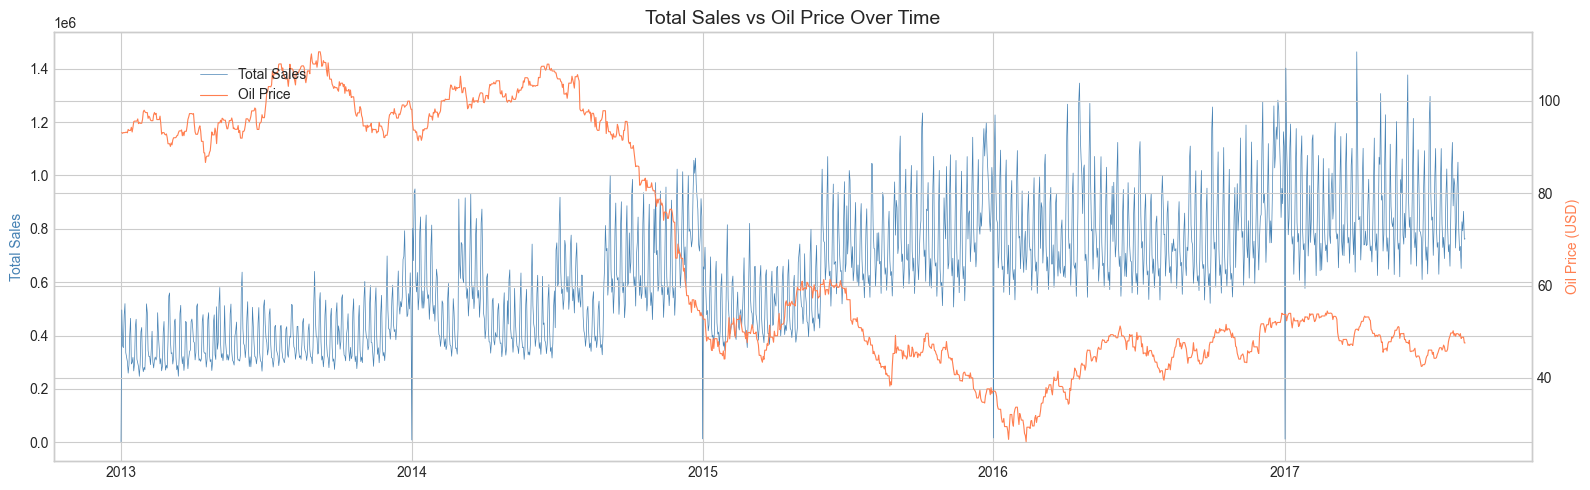

In [20]:
# Merge oil prices with daily sales
daily_sales_df = train.groupby('date')['sales'].sum().reset_index()
daily_sales_oil = daily_sales_df.merge(oil, on='date', how='left')

# Forward fill oil prices (markets closed on weekends)
daily_sales_oil['dcoilwtico'] = daily_sales_oil['dcoilwtico'].ffill()

fig, ax1 = plt.subplots(figsize=(16, 5))

ax1.plot(daily_sales_oil['date'], daily_sales_oil['sales'], 
         linewidth=0.5, color='steelblue', label='Total Sales')
ax1.set_ylabel('Total Sales', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(daily_sales_oil['date'], daily_sales_oil['dcoilwtico'], 
         linewidth=0.8, color='coral', label='Oil Price')
ax2.set_ylabel('Oil Price (USD)', color='coral')

ax1.set_title('Total Sales vs Oil Price Over Time', fontsize=14)
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

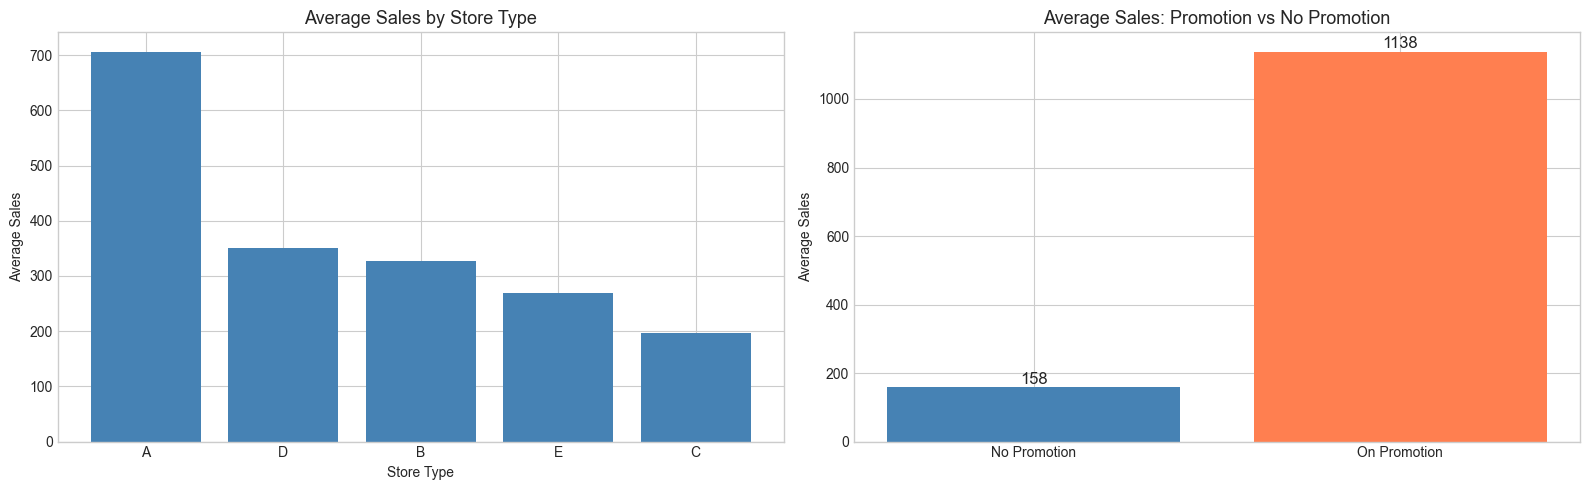

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sales by store type
train_stores = train.merge(stores, on='store_nbr')
type_sales = train_stores.groupby('type')['sales'].mean().sort_values(ascending=False)
axes[0].bar(type_sales.index, type_sales.values, color='steelblue')
axes[0].set_title('Average Sales by Store Type', fontsize=13)
axes[0].set_xlabel('Store Type')
axes[0].set_ylabel('Average Sales')

# Promotion effect
promo_sales = train.groupby('onpromotion')['sales'].mean()
# Just compare: no promo vs has promo
no_promo = train[train['onpromotion'] == 0]['sales'].mean()
has_promo = train[train['onpromotion'] > 0]['sales'].mean()

axes[1].bar(['No Promotion', 'On Promotion'], [no_promo, has_promo], 
            color=['steelblue', 'coral'])
axes[1].set_title('Average Sales: Promotion vs No Promotion', fontsize=13)
axes[1].set_ylabel('Average Sales')

for i, v in enumerate([no_promo, has_promo]):
    axes[1].text(i, v + 10, f'{v:.0f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

Store types matter a lot. Type A stores sell more than 3x what Type C stores sell. This means store type will be a powerful feature — we can't treat all stores the same. Type A stores are likely larger format or in higher-traffic locations.
Promotions are massive. Items on promotion average 1,138 in sales versus 158 without — that's a 7x multiplier. This is arguably the single most important feature in the entire dataset. If we know something is going on promotion, we can predict a huge sales jump. This is exactly the kind of insight that makes demand forecasting valuable in the real world — a supply chain manager needs to stock up heavily before a promotion runs.

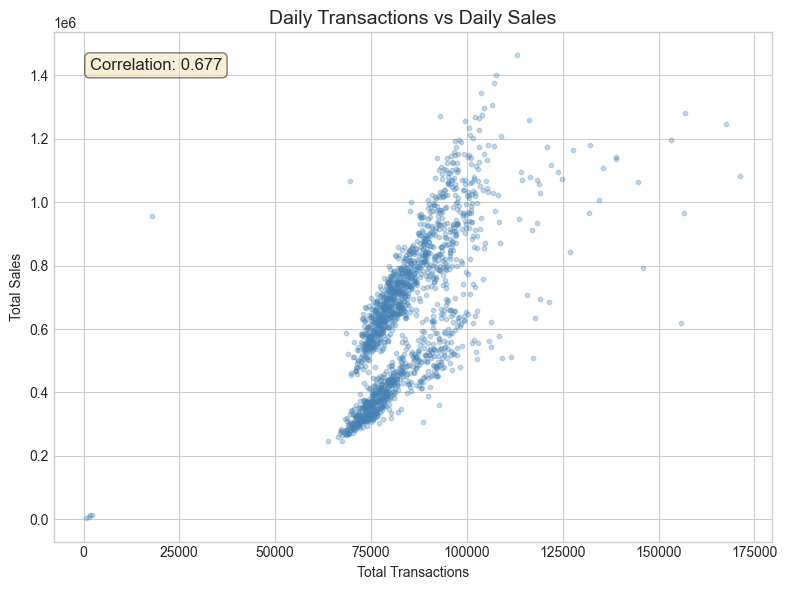

In [22]:
# Let's check the correlation between transactions and sales
daily_trans = transactions.groupby('date')['transactions'].sum().reset_index()
daily_sales_trans = daily_sales_df.merge(daily_trans, on='date', how='inner')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(daily_sales_trans['transactions'], daily_sales_trans['sales'], 
           alpha=0.3, s=10, color='steelblue')
ax.set_title('Daily Transactions vs Daily Sales', fontsize=14)
ax.set_xlabel('Total Transactions')
ax.set_ylabel('Total Sales')

# Calculate correlation
corr = daily_sales_trans['transactions'].corr(daily_sales_trans['sales'])
ax.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax.transAxes, 
        fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()